## CPE 4903 - Prediction of Time Series: RNN ##
Predict [y(t+n)] given x(t-time_steps)...x(t), x(t) = [1 2 3 4 5 4 3 2 1 2 3 ...] sawtooth

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense, Dropout, LSTM, SimpleRNN
from keras.models import Model, Sequential
import pandas as pd
#import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
import os  # avoid kernal die
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
def plot_loss(history, title):
# summarize history for loss
    plt.figure(figsize = (10, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss: ' + title)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()
    print('MSE val = ', history.history['val_loss'][-1])

In [4]:
def plot_y_yhat(x_test, y_test, model, title):
#y_pred = model.predict(X_test)
    y_hat = model.predict(x_test)
    Time_test = np.arange(0, len(y_hat))
    plt.figure(figsize=(10,5))
    plt.plot(Time_test, y_hat, '-+', Time_test, y_test)
    plt.xlabel("Days in data set")
    plt.ylabel("Scaled Stock Prices")
    plt.legend(['Predicted', 'True'], loc='upper right')
    plt.title('Y vs Yhat: ' + title)
    results = model.evaluate(x_test, y_test)
    print("test loss, test acc:", results)

In [5]:
# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)
# tf.random.set_seed(RANDOM_SEED)

In [6]:
df = pd.read_csv("AAPL_hist_data.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,3/29/2022,176.690002,179.009995,176.339996,178.960007,177.882446,100589400
1,3/30/2022,178.550003,179.610001,176.699997,177.770004,176.699615,92633200
2,3/31/2022,177.839996,178.029999,174.399994,174.610001,173.558640,103049300
3,4/1/2022,174.029999,174.880005,171.940002,174.309998,173.260437,78751300
4,4/4/2022,174.570007,178.490005,174.440002,178.440002,177.365570,76468400
...,...,...,...,...,...,...,...
246,3/22/2023,159.300003,162.139999,157.809998,157.830002,157.830002,75701800
247,3/23/2023,158.830002,161.550003,157.679993,158.929993,158.929993,67622100
248,3/24/2023,158.860001,160.339996,157.850006,160.250000,160.250000,59196500
249,3/27/2023,159.940002,160.770004,157.869995,158.279999,158.279999,52390300


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       251 non-null    datetime64[ns]
 1   Open       251 non-null    float64       
 2   High       251 non-null    float64       
 3   Low        251 non-null    float64       
 4   Close      251 non-null    float64       
 5   Adj Close  251 non-null    float64       
 6   Volume     251 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.9 KB
None


In [8]:
#ensure that all info is sorted by dates
df.sort_values(by = "Date", inplace = True)
df.reset_index(drop = True, inplace = True)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-03-29,176.690002,179.009995,176.339996,178.960007,177.882446,100589400
1,2022-03-30,178.550003,179.610001,176.699997,177.770004,176.699615,92633200
2,2022-03-31,177.839996,178.029999,174.399994,174.610001,173.558640,103049300
3,2022-04-01,174.029999,174.880005,171.940002,174.309998,173.260437,78751300
4,2022-04-04,174.570007,178.490005,174.440002,178.440002,177.365570,76468400
...,...,...,...,...,...,...,...
246,2023-03-22,159.300003,162.139999,157.809998,157.830002,157.830002,75701800
247,2023-03-23,158.830002,161.550003,157.679993,158.929993,158.929993,67622100
248,2023-03-24,158.860001,160.339996,157.850006,160.250000,160.250000,59196500
249,2023-03-27,159.940002,160.770004,157.869995,158.279999,158.279999,52390300


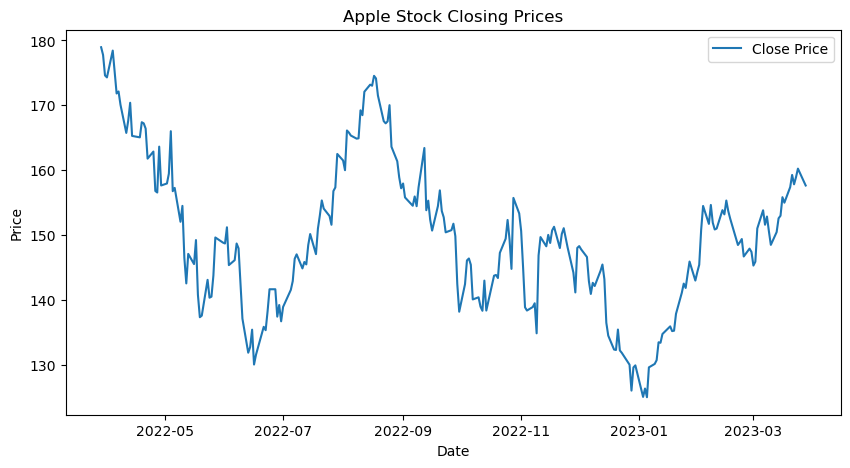

In [9]:
plt.figure(figsize = (10, 5))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.title("Apple Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [10]:
prices = df['Close'].values.reshape(-1, 1)

In [11]:
#scales data from range of 0-1
scaler = MinMaxScaler(feature_range = (0, 1))
prices_scaled = scaler.fit_transform(prices)

In [12]:
#Tuneable Hyperperameters
time_steps = 40
n = 3               # How far steps ahead to predict: y(t + n)

# splits the training and test data set in 80% : 20%
train, test = train_test_split(prices_scaled, test_size = 0.2, shuffle = False)

m_train = len(train)
m_star_train = m_train - time_steps - n + 1

X_train = np.zeros((m_star_train, time_steps))
y_train = np.zeros((m_star_train, 1))
#X_train.shape
for i in range(m_star_train):
    X_train[i, :] = train[i : i + time_steps].flatten()
    y_train[i] = train[i + time_steps - 1 + n]

m_test = len(test)
m_star_test = m_test - time_steps - n + 1

X_test = np.zeros((m_star_test, time_steps))
y_test = np.zeros((m_star_test, 1))

for i in range(m_star_test):
    X_test[i, :] = test[i : i + time_steps].flatten()
    y_test[i] = test[i + time_steps - 1 + n]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)  # Expected: (number of training sequences, time_steps, 1)
print("y_train shape:", y_train.shape)  # Expected: (number of training sequences, 1)
print("X_test shape:", X_test.shape)    # Expected: (number of test sequences, time_steps, 1)
print("y_test shape:", y_test.shape)    # Expected: (number of test sequences, 1)

X_train shape: (158, 40, 1)
y_train shape: (158, 1)
X_test shape: (9, 40, 1)
y_test shape: (9, 1)


In [13]:
m = len(y_train)
nx = 1 # dim of x<t>
print('m, time_steps, n = look_ahead, nx: ', m, time_steps, n, nx)

m, time_steps, n = look_ahead, nx:  158 40 3 1


In [14]:
# RNN #
hidden_neurons = 128

model = Sequential()
model.add(SimpleRNN(units = hidden_neurons, return_sequences = True, input_shape = (time_steps, nx)))

model.add(SimpleRNN(units = hidden_neurons, return_sequences = False))


# Just add 1 output value (next days value)
model.add(Dense(units = 1))

opt=keras.optimizers.Adam()

model.compile(loss='mean_squared_error',optimizer=opt)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 40, 128)           16640     
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 128)               32896     
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 49,665
Trainable params: 49,665
Non-trainable params: 0
_________________________________________________________________


In [15]:
#Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

# Evaluates performance on the test set
# The 'loss' here is MSE on the test set
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Loss (MSE): {test_loss:.6f}")

Epoch 1/50
2/2 [==============================] - 2s 634ms/step - loss: 0.4589 - val_loss: 0.3754
Epoch 2/50
2/2 [==============================] - 0s 66ms/step - loss: 0.2408 - val_loss: 0.2863
Epoch 3/50
2/2 [==============================] - 0s 73ms/step - loss: 0.6111 - val_loss: 0.0445
Epoch 4/50
2/2 [==============================] - 0s 71ms/step - loss: 0.0477 - val_loss: 0.2996
Epoch 5/50
2/2 [==============================] - 0s 70ms/step - loss: 0.1075 - val_loss: 0.0173
Epoch 6/50
2/2 [==============================] - 0s 69ms/step - loss: 0.0292 - val_loss: 0.0162
Epoch 7/50
2/2 [==============================] - 0s 64ms/step - loss: 0.1070 - val_loss: 0.0501
Epoch 8/50
2/2 [==============================] - 0s 67ms/step - loss: 0.0314 - val_loss: 0.1180
Epoch 9/50
2/2 [==============================] - 0s 81ms/step - loss: 0.0369 - val_loss: 0.0524
Epoch 10/50
2/2 [==============================] - 0s 70ms/step - loss: 0.0246 - val_loss: 0.0083
Epoch 11/50
2/2 [===========

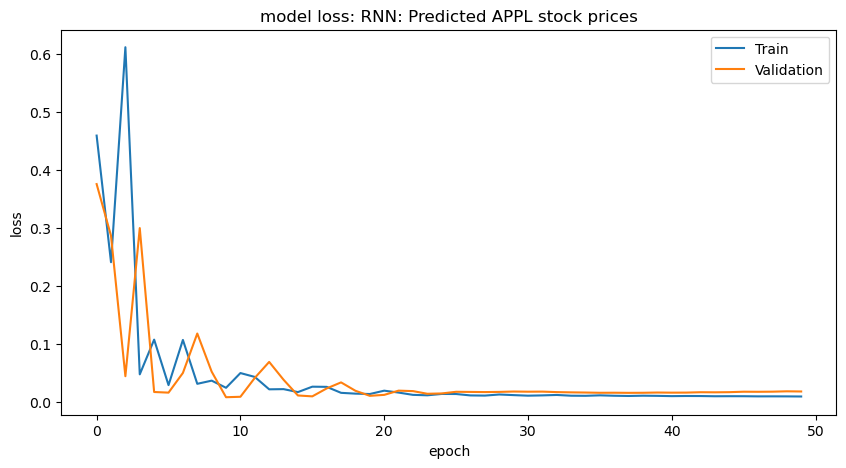

MSE val =  0.01818288303911686
5/5 [==============================] - 0s 10ms/step - loss: 0.0104
test loss, test acc: 0.010439633391797543


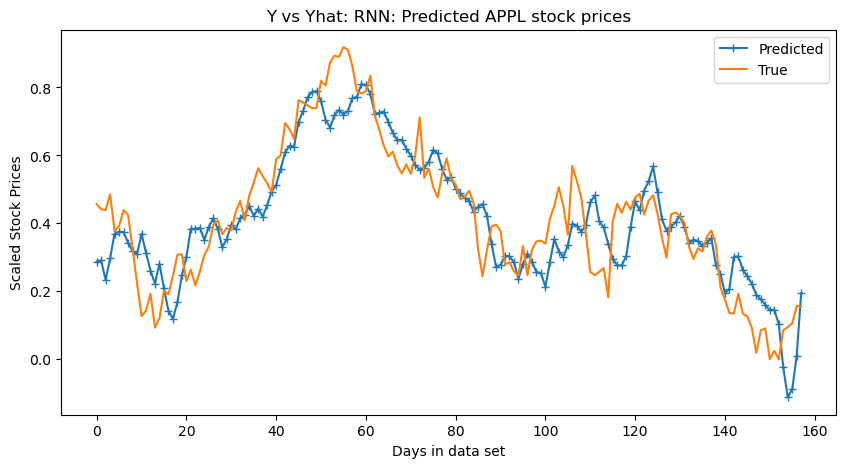

In [16]:
plot_loss(history, 'RNN: Predicted APPL stock prices')

plot_y_yhat(X_train, y_train, model, 'RNN: Predicted APPL stock prices')   # runs model.predict in function

1/1 [==============================] - 0s 42ms/step - loss: 0.0275
test loss, test acc: 0.02751305140554905


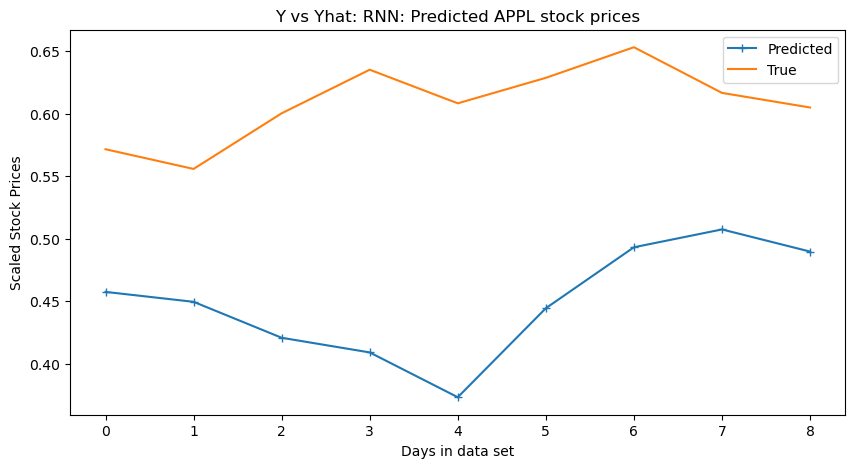

In [17]:
yhat_test = model.predict(X_test)
plot_y_yhat(X_test, y_test, model, 'RNN: Predicted APPL stock prices')   # runs model.predict in function

1/1 [==============================] - 0s 23ms/step
Mean Error: -5.42%
Mean Absolute Error: 5.42%
Percentage of test points within +/-10%: 100.00%


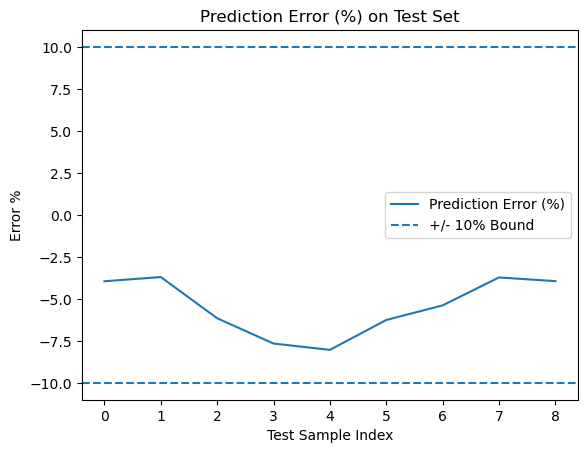

In [18]:
# Calculate Prediction Error (%) for each test point
predictions_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predictions_scaled)
actual_prices = scaler.inverse_transform(y_test)

errors = 100 * (predicted_prices.flatten() - actual_prices.flatten()) / actual_prices.flatten()

# Print Metrics
mean_error = np.mean(errors)
mae_error = np.mean(np.abs(errors))
within_10pct = np.mean(np.abs(errors) <= 10) * 100.0

print(f"Mean Error: {mean_error:.2f}%")
print(f"Mean Absolute Error: {mae_error:.2f}%")
print(f"Percentage of test points within +/-10%: {within_10pct:.2f}%")

# Plot the error percentage over each test sample
plt.figure()
plt.plot(range(len(errors)), errors, label="Prediction Error (%)")
plt.axhline(10, linestyle="--", label="+/- 10% Bound")
plt.axhline(-10, linestyle="--")
plt.title("Prediction Error (%) on Test Set")
plt.xlabel("Test Sample Index")
plt.ylabel("Error %")
plt.legend()
plt.show()